  
## Gotta Graph ’Em All! — Explorando a 1ª geração Pokémon com dados 

---

Farei uso das bibliotecas:
Pandas e Numpy: para manipulação de dados.
Matplotlib e Seaborn: para visualização de dados.
PIL: para manipulação de imagens.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

In [2]:
data = pd.read_csv('pokemons_kanto.csv', encoding='latin-1')

## Pokémons rápidos tendem a ser mais fortes?
---

Se você nunca jogou pokémon, talvez seja uma novidade para você, mas o pokémon com mais velocidade ataca primeiro em uma batalha. Isso pode ser uma vantagem estratégica, já que o pokémon mais rápido pode causar dano antes que o adversário tenha a chance de atacar. Tendo isso em mente, será que pokémons com mais pontos de velocidade também tendem a ser mais fortes em termos de pontos de ataque?
Para responder essa pergunta, podemos criar um gráfico de dispersão que mostra a relação entre os pontos de velocidade e os pontos de ataque dos pokémons da 1ª geração. Cada ponto no gráfico representa um pokémon, com a velocidade no eixo x e o ataque no eixo y.

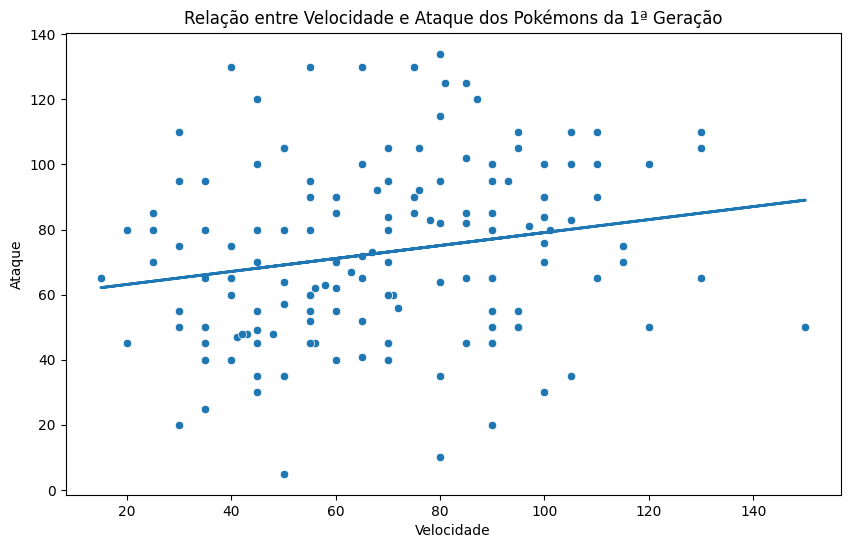

In [3]:
x = data['Velocidade']
y = data['Ataque']

# Ajuste da reta de tendência (regressão linear)
coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef)

plt.figure(figsize=(10,6))
sns.scatterplot(data=data, x='Velocidade', y='Ataque')
# Linha de tendência
plt.plot(x, poly1d_fn(x), lw=2)
plt.title('Relação entre Velocidade e Ataque dos Pokémons da 1ª Geração')
plt.xlabel('Velocidade')
plt.ylabel('Ataque')
plt.show()

A partir desse gráfico, podemos observar se há uma correlação positiva entre velocidade e ataque. Se os pontos no gráfico formarem uma tendência ascendente, isso indicaria que pokémons mais rápidos tendem a ter pontos de ataque mais altos. Caso contrário, se os pontos estiverem dispersos sem um padrão claro, isso sugeriria que não há uma relação significativa entre essas duas características.
Como podemos ver, há uma certa tendência de que pokémons mais rápidos também tenham pontos de ataque mais altos, embora existam exceções. Portanto, podemos concluir que, em geral, pokémons rápidos tendem a ser mais fortes em termos de ataque, mas essa não é uma regra absoluta.

# E se o Pikachu do Ash evoluísse?
---

A menos que você tenha vivido em uma caverna, provavelmente já ouviu falar sobre a evolução dos pokémons. A evolução é um processo pelo qual um pokémon se transforma em uma forma mais avançada, geralmente ganhando novos poderes e habilidades. Não há dúvidas que o Pikachu do Ash é formidável, mas será que ele ficaria ainda mais forte se evoluísse para Raichu?
Para responder essa pergunta, podemos comparar os pontos totais (Total Points) de Pikachu e Raichu. Os pontos totais são a soma de todas as características de um pokémon, incluindo HP, ataque, defesa, ataque especial, defesa especial e velocidade. Quanto maior o total de pontos, mais forte é o pokémon.

In [4]:
# Coletando os dados de Pikachu e Raichu
nome = 'pikachu'
pikachu_dados = data.loc[data['Nome'] == nome]

nome = 'raichu'
raichu_dados = data.loc[data['Nome'] == nome]


In [5]:

stat_cols = ['HP', 'Ataque', 'Defesa', 'Ataque Especial', 'Defesa Especial', 'Velocidade']

# Somar os stats base do Pikachu
total_pikachu = pikachu_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Raichu
total_raichu = raichu_dados[stat_cols].sum(axis=1).iloc[0]

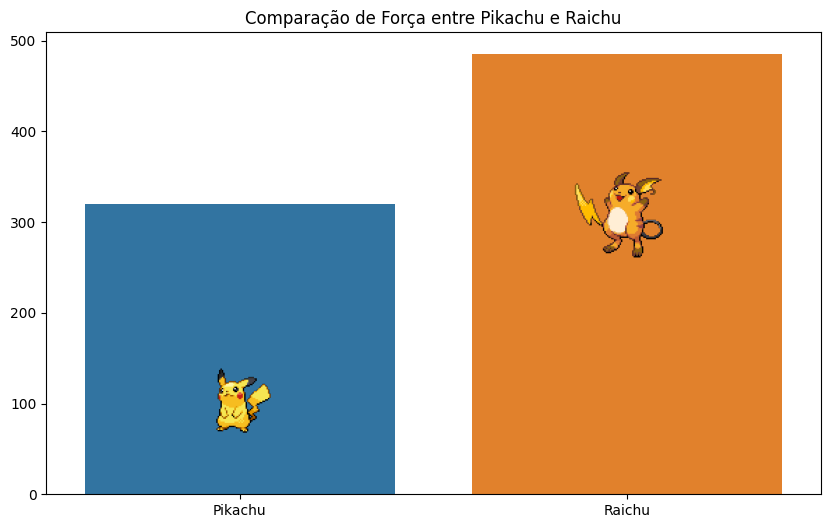

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
#carregando a imagem do pikachu
img = Image.open("sprites/25.png").convert("RGBA")
imagebox = OffsetImage(img, zoom=1)
ab = AnnotationBbox(imagebox, (0.25, 0.2), xycoords='axes fraction', frameon=False)
ax.add_artist(ab)

#carregando a imagem do raichu
img2 = Image.open("sprites/26.png").convert("RGBA")
imagebox2 = OffsetImage(img2, zoom=1)
ab2 = AnnotationBbox(imagebox2, (0.75, 0.6), xycoords='axes fraction', frameon=False)
ax.add_artist(ab2)

sns.barplot(x=['Pikachu', 'Raichu'], y=[total_pikachu, total_raichu], hue=['Pikachu', 'Raichu'])
plt.title('Comparação de Força entre Pikachu e Raichu')
plt.show()

Uau! Esse choque do trovão foi poderoso! Como podemos ver no gráfico, Raichu, a forma evoluída de Pikachu, tem um Total Points significativamente maior do que Pikachu. Isso sugere que, pelo menos nesse caso específico, a evolução resulta em um pokémon mais forte. Portanto, podemos concluir que Ash faria bem em deixar seu Pikachu evoluir para Raichu, se ele quiser aumentar suas chances de vitória nas batalhas.(O que os torna verdadeiramente fortes é o vínculo que eles compartilham com seus treinadores, afinal de contas.)

# Qual o melhor pokémon inicial?
---

Uma das decisões mais desafiadoras que um treinador de pokémon enfrenta é escolher seu pokémon inicial. Na 1ª geração, os treinadores podiam escolher entre Bulbasaur, Charmander e Squirtle. Cada um desses pokémons tem suas próprias vantagens e desvantagens, mas qual deles é o melhor em termos de força total?
Para responder essa pergunta, vamos analisar um gráfico de linhas que mostra os pontos totais (Total Points) de cada um dos pokémons iniciais ao longo das suas evoluções. Cada linha no gráfico representa um pokémon inicial, e o eixo y mostra os pontos totais e o eixo x mostra as diferentes formas evoluídas (níveis) de cada pokémon.

In [7]:
# Coletando os dados da linha evolutiva de Bulbasaur
bulbasaur_dados = data.loc[data['Nome'] == "bulbasaur"]
ivysaur_dados = data.loc[data['Nome'] == "ivysaur"]
venusaur_dados = data.loc[data['Nome'] == "venusaur"]

# Coletando os dados da linha evolutiva de Charmander
charmander_dados = data.loc[data['Nome'] == "charmander"]
charmeleon_dados = data.loc[data['Nome'] == "charmeleon"]
charizard_dados = data.loc[data['Nome'] == "charizard"]

# Coletando os dados da linha evolutiva de Squirtle
squirtle_dados = data.loc[data['Nome'] == "squirtle"]
wartortle_dados = data.loc[data['Nome'] == "wartortle"]
blastoise_dados = data.loc[data['Nome'] == "blastoise"]

In [8]:
stat_cols = ['HP', 'Ataque', 'Defesa', 'Ataque Especial', 'Defesa Especial', 'Velocidade']

# Somar os stats base do Bulbasaur
total_bulbasaur = bulbasaur_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Ivysaur
total_ivysaur = ivysaur_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Venusaur
total_venusaur = venusaur_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Charmander
total_charmander = charmander_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Charmeleon
total_charmeleon = charmeleon_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Charizard
total_charizard = charizard_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Squirtle
total_squirtle = squirtle_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Wartortle
total_wartortle = wartortle_dados[stat_cols].sum(axis=1).iloc[0]

# Somar os stats base do Blastoise  
total_blastoise = blastoise_dados[stat_cols].sum(axis=1).iloc[0]

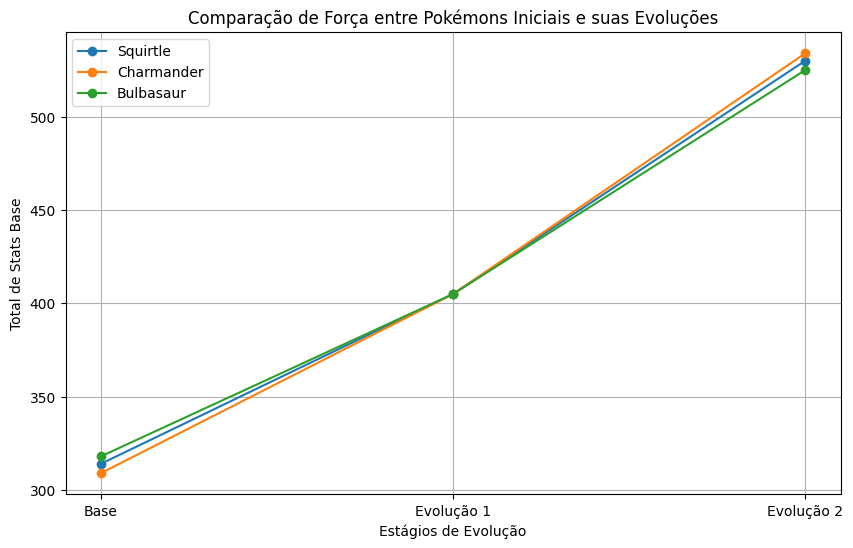

In [9]:
estagios = ['Base', 'Evolução 1', 'Evolução 2'] 

bulbasaur = [total_bulbasaur, total_ivysaur, total_venusaur]
charmander = [total_charmander, total_charmeleon, total_charizard]
squirtle = [total_squirtle, total_wartortle, total_blastoise]

plt.figure(figsize=(10, 6))
plt.plot(estagios, squirtle, marker='o', label='Squirtle')
plt.plot(estagios, charmander, marker='o', label='Charmander')
plt.plot(estagios, bulbasaur, marker='o', label='Bulbasaur')
plt.xlabel('Estágios de Evolução')
plt.ylabel('Total de Stats Base')
plt.title('Comparação de Força entre Pokémons Iniciais e suas Evoluções')
plt.legend()
plt.grid(True)
plt.show()

Como podemos podemos ver no gráfico, os três iniciais evoluem de formas quase idênticas em termos de Total Points. São iguais em seus primeiros estágios! No entanto, ao atingirem suas formas finais, Charizard (evolução final de Charmander) se destaca ligeiramente com o maior Total Points, seguido por Blastoise (evolução final de Squirtle) e Venusaur (evolução final de Bulbasaur). Portanto, se estivermos apenas considerando a força total, Charmander seria a melhor escolha entre os pokémons iniciais da 1ª geração. No entanto, é importante lembrar que a escolha do pokémon inicial também depende do estilo de jogo e das preferências pessoais de cada treinador.

# Quais os tipos de pokémons mais comuns na 1ª geração?
---

Essa pergunta pode despertar na nossa cabeça a imagem de pokémons normais como Pidgey e Rattata, que são frequentemente encontrados em várias áreas do jogo. No entanto, para responder a essa pergunta de forma mais precisa, podemos criar um gráfico de barras que mostra os 5 tipos primários mais comuns entre os pokémons da 1ª geração.
Isso pode nos dar insights sobre as estratégias de jogo, já que diferentes tipos de pokémons têm vantagens e desvantagens em batalhas contra outros tipos.

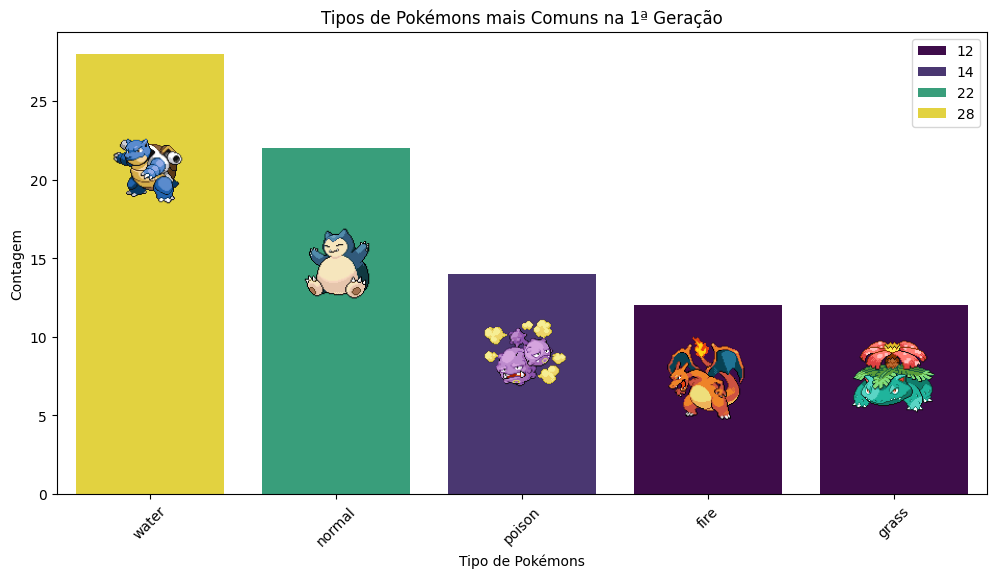

In [10]:
tipos_primarios = data['Tipo1'].value_counts() # Contagem dos tipos primários
tipos_primarios = tipos_primarios.head(5) # Seleciona os 5 tipos mais comuns

fig, ax = plt.subplots(figsize=(12, 6))
#carregando a imagem do blastoise
img = Image.open("sprites/9.png").convert("RGBA")
imagebox = OffsetImage(img, zoom=0.75)
ab = AnnotationBbox(imagebox, (0.10, 0.7), xycoords='axes fraction', frameon=False)
ax.add_artist(ab)

#carregando a imagem do snorlax
img2 = Image.open("sprites/143.png").convert("RGBA")
imagebox2 = OffsetImage(img2, zoom=0.75)
ab2 = AnnotationBbox(imagebox2, (0.3, 0.5), xycoords='axes fraction', frameon=False)
ax.add_artist(ab2)

#carregando a imagem do weezing
img3 = Image.open("sprites/110.png").convert("RGBA")
imagebox3 = OffsetImage(img3, zoom=0.75)
ab3 = AnnotationBbox(imagebox3, (0.5, 0.3), xycoords='axes fraction', frameon=False)
ax.add_artist(ab3)

#carregando a imagem do charizard
img4 = Image.open("sprites/6.png").convert("RGBA")
imagebox4 = OffsetImage(img4, zoom=0.75)
ab4 = AnnotationBbox(imagebox4, (0.7, 0.25), xycoords='axes fraction', frameon=False)
ax.add_artist(ab4)

#carregando a imagem do venasaur
img5 = Image.open("sprites/3.png").convert("RGBA")
imagebox5 = OffsetImage(img5, zoom=0.75)
ab5 = AnnotationBbox(imagebox5, (0.9, 0.25), xycoords='axes fraction', frameon=False)
ax.add_artist(ab5)

sns.barplot(x=tipos_primarios.index, y=tipos_primarios.values, hue=tipos_primarios.values, palette='viridis')
plt.xlabel('Tipo de Pokémons')
plt.ylabel('Contagem')
plt.title('Tipos de Pokémons mais Comuns na 1ª Geração')
plt.xticks(rotation=45)
plt.show()

Quem diria que os pokémons do tipo Água seriam os mais comuns na 1ª geração? Isso pode ser atribuído à presença de muitos pokémons aquáticos em áreas como lagos, rios e oceanos no jogo, tal qual o mundo real. Além disso, tipos como Normal, Planta, Inseto e Fogo também são bastante prevalentes, refletindo a diversidade de habitats e ecossistemas presentes no mundo dos pokémons. Essa distribuição de tipos pode influenciar as estratégias dos jogadores ao escolherem seus times para batalhas e aventuras.

# Qual a média de vida em Kanto?
---

Bom, uma batalha pokémon acaba quando um dos pokémons fica sem vida (HP = 0). Portanto, a quantidade de pontos de vida (HP) de um pokémon é crucial para sua sobrevivência em batalhas. Mas qual é a média de pontos de vida dos pokémons na região de Kanto, onde a 1ª geração se passa?
Para responder essa pergunta, podemos exibir um boxplot que mostra a distribuição dos pontos de vida (HP) dos pokémons da 1ª geração. O boxplot nos permite visualizar a mediana, os quartis e os valores atípicos dos pontos de vida, dando-nos uma ideia clara da média e da variação dos HPs entre os pokémons.

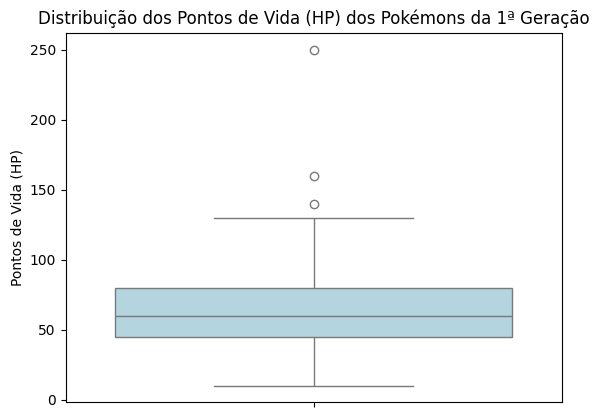

In [11]:
sns.boxplot(y='HP', data=data, color='lightblue')
plt.title('Distribuição dos Pontos de Vida (HP) dos Pokémons da 1ª Geração')
plt.ylabel('Pontos de Vida (HP)')
plt.show()

A partir do gráfico, podemos observar que a mediana dos pontos de vida (HP) dos pokémons da 1ª geração está em torno de 60. Isso indica que metade dos pokémons tem HP abaixo desse valor e a outra metade acima. Além disso, o boxplot mostra que a maioria dos pokémons tem HP entre aproximadamente 45 e 75, com alguns valores atípicos que indicam pokémons com HP muito altos. Portanto, podemos concluir que a média de vida dos pokémons em Kanto é moderada, com uma variação significativa entre diferentes espécies.

# Top 3 HPs mais altos da 1ª geração
---

O último gráfico pode atiçar em nós uma pequena curiosidade: quais são os pokémons com os maiores pontos de vida (HP) na 1ª geração? Para responder a essa pergunta, podemos criar um gráfico de barras que mostra os 3 pokémons com os maiores valores de HP. Seria o Snorlax o campeão invicto?

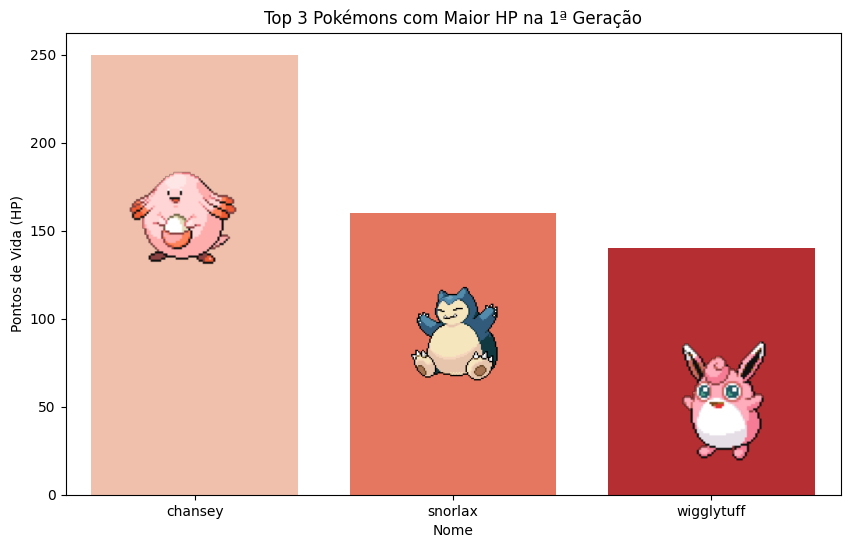

In [12]:
maiores_hp = data.nlargest(3, 'HP')[['Nome', 'HP']] # Seleciona os 3 pokémons com maior HP

fig, ax = plt.subplots(figsize=(10, 6))
#carregando a imagem da chansey
img = Image.open("sprites/113.png").convert("RGBA")
imagebox = OffsetImage(img, zoom=1.5)
ab = AnnotationBbox(imagebox, (0.15, 0.6), xycoords='axes fraction', frameon=False)
ax.add_artist(ab)

#carregando a imagem do snorlax
img2 = Image.open("sprites/143.png").convert("RGBA")
imagebox2 = OffsetImage(img2, zoom=1)
ab2 = AnnotationBbox(imagebox2, (0.5, 0.35), xycoords='axes fraction', frameon=False)
ax.add_artist(ab2)

#carregando a imagem do Wigglytuff
img3 = Image.open("sprites/40.png").convert("RGBA")
imagebox3 = OffsetImage(img3, zoom=1.5)
ab3 = AnnotationBbox(imagebox3, (0.85, 0.2), xycoords='axes fraction', frameon=False)
ax.add_artist(ab3)

sns.barplot(x='Nome', y='HP', data=maiores_hp, hue = 'Nome', palette='Reds')
plt.title('Top 3 Pokémons com Maior HP na 1ª Geração')
plt.ylabel('Pontos de Vida (HP)')
plt.show()

Mais um gráfico que - com certeza - surpreenderá a muitos, Chansey lidera, quase 100 pontos à frente de Snorlax em questão de pontos de vida(HP) se consagrando o campeão de HP em Kanto. Isso se deve ao fato de Chansey ser conhecido por sua incrível resistência e capacidade de cura, tornando-o um pokémon difícil de derrotar em batalhas. Snorlax, embora também tenha um HP impressionante, fica em segundo lugar, seguido por Wigglytuff. Esses pokémons são verdadeiros tanques no campo de batalha, capazes de absorver uma quantidade significativa de dano antes de serem derrotados.

# Qual o top 5 de pokémons de Kanto?
---

Para responder a essa pergunta, podemos criar um gráfico de barras que mostra os 5 pokémons com os maiores pontos totais (Total Points) na 1ª geração. Isso nos dará uma ideia clara de quais pokémons são considerados os mais fortes em termos de suas características combinadas. Será que Mewtwo lidera esse ranking?

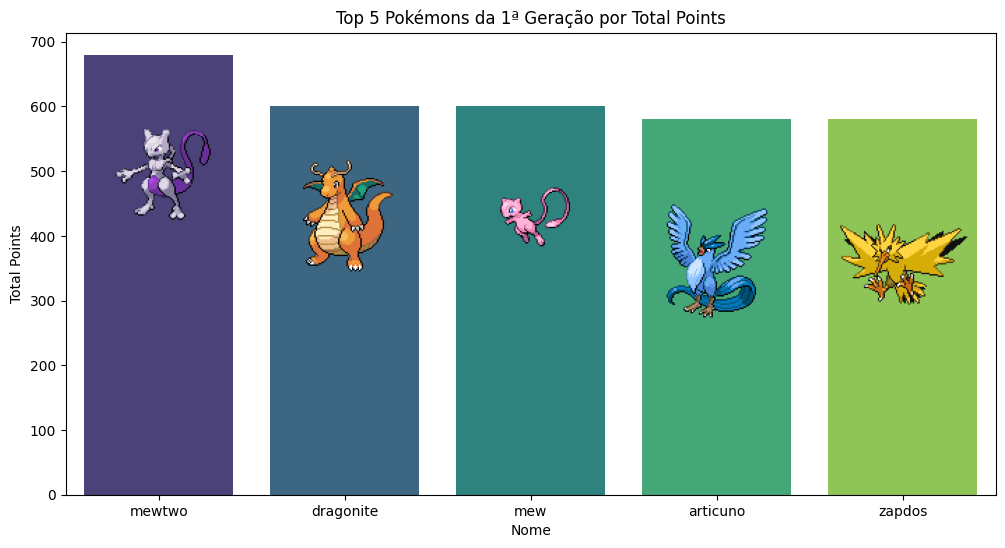

In [26]:
# Calcula a soma dos stats base (reaproveita stat_cols já definidos)
data['Total Points'] = data[stat_cols].sum(axis=1)

# Seleciona os top 5 por Total Points
top5 = data.nlargest(5, 'Total Points')[['Nome', 'Total Points']].reset_index(drop=True)

# Plotando o gráfico de barras
fig, ax = plt.subplots(figsize=(12, 6))

# Carregando imagem de Mewtwo
img = Image.open("sprites/150.png").convert("RGBA")
imagebox = OffsetImage(img, zoom=1)
ab = AnnotationBbox(imagebox, (0.1, 0.7), xycoords='axes fraction', frameon=False)
ax.add_artist(ab)

# Carregando imagem de Dragonite
img2 = Image.open("sprites/149.png").convert("RGBA")
imagebox2 = OffsetImage(img2, zoom=1)
ab2 = AnnotationBbox(imagebox2, (0.3, 0.6), xycoords='axes fraction', frameon=False)
ax.add_artist(ab2)

# Carregando imagem de Mew
img3 = Image.open("sprites/151.png").convert("RGBA")
imagebox3 = OffsetImage(img3, zoom=1)
ab3 = AnnotationBbox(imagebox3, (0.5, 0.6), xycoords='axes fraction', frameon=False)
ax.add_artist(ab3)

# Carregando imagem de Articuno
img4 = Image.open("sprites/144.png").convert("RGBA")
imagebox4 = OffsetImage(img4, zoom=1)
ab4 = AnnotationBbox(imagebox4, (0.7, 0.5), xycoords='axes fraction', frameon=False)
ax.add_artist(ab4)

# Carregando imagem de Zapdos
img5 = Image.open("sprites/145.png").convert("RGBA")
imagebox5 = OffsetImage(img5, zoom=1)
ab5 = AnnotationBbox(imagebox5, (0.9, 0.5), xycoords='axes fraction', frameon=False)
ax.add_artist(ab5)

# Gráfico de barras
sns.barplot(data=top5, x='Nome', y='Total Points',hue='Nome', palette='viridis', ax=ax)
ax.set_title('Top 5 Pokémons da 1ª Geração por Total Points')
plt.show()

Como podemos ver no gráfico, Mewtwo realmente lidera o ranking com o maior Total Points entre os pokémons da 1ª geração. Isso não é surpreendente, considerando que Mewtwo é um pokémon lendário conhecido por sua força e habilidades excepcionais. Seguindo Mewtwo, temos Dragonite, que também é um pokémon muito poderoso, seguido por outros pokémons notáveis como Mew, Articuno e Zapdos. Esses pokémons são verdadeiros titãs no universo Pokémon, cada um com suas próprias habilidades únicas que os tornam formidáveis em batalhas. Curioso pensar que Dragonite empata com Mew em Total Points, não é mesmo? Sem falar de Articuno e Zapdos que também ficam empatados logo atrás.